In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder

In [ ]:
df1 = pd.read_csv('/content/aqi.csv')
df1

,date,state,area,number_of_monitoring_stations,prominent_pollutants,aqi_value,air_quality_status,unit,note
0,30-04-2025,Maharashtra,Amravati,2,PM10,78,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN
1,30-04-2025,Bihar,Purnia,1,CO,56,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN
2,30-04-2025,Madhya Pradesh,Katni,1,O3,98,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN
3,30-04-2025,Chhattisgarh,Tumidih,1,PM10,103,Moderate,number_of_monitoring_stations in Absolute Numb...,NaN
4,30-04-2025,Assam,Byrnihat,1,PM2.5,61,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN
...,...,...,...,...,...,...,...,...,...
235780,01-04-2022,Bihar,Arrah,1,PM10,210,Poor,number_of_monitoring_stations in Absolute Numb...,NaN
235781,01-04-2022,Rajasthan,Jaipur,3,"PM2.5,PM10",158,Moderate,number_of_monitoring_stations in Absolute Numb...,NaN
235782,01-04-2022,Maharashtra,Chandrapur,2,PM2.5,201,Poor,number_of_monitoring_stations in Absolute Numb...,NaN
235783,01-04-2022,Uttar Pradesh,Varanasi,4,PM10,128,Moderate,number_of_monitoring_stations in Absolute Numb...,NaN


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235785 entries, 0 to 235784
Data columns (total 9 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   date                           235785 non-null  object 
 1   state                          235785 non-null  object 
 2   area                           235785 non-null  object 
 3   number_of_monitoring_stations  235785 non-null  int64  
 4   prominent_pollutants           235785 non-null  object 
 5   aqi_value                      235785 non-null  int64  
 6   air_quality_status             235785 non-null  object 
 7   unit                           235785 non-null  object 
 8   note                           0 non-null       float64
dtypes: float64(1), int64(2), object(6)
memory usage: 16.2+ MB


In [ ]:
df1.describe()

,number_of_monitoring_stations,aqi_value,note
count,235785.000000,235785.000000,0.0
mean,1.870653,111.127294,NaN
std,3.071575,71.447353,NaN
min,1.000000,3.000000,NaN
25%,1.000000,59.000000,NaN
50%,1.000000,92.000000,NaN
75%,1.000000,142.000000,NaN
max,40.000000,500.000000,NaN


In [ ]:
df1.isnull().sum()/len(df1)*100

,0
date,0.0
state,0.0
area,0.0
number_of_monitoring_stations,0.0
prominent_pollutants,0.0
aqi_value,0.0
air_quality_status,0.0
unit,0.0
note,100.0


In [ ]:
df1.drop(columns=['unit','note','date'],inplace=True,axis=1)

In [ ]:
df1.isnull().sum()

,0
state,0
area,0
number_of_monitoring_stations,0
prominent_pollutants,0
aqi_value,0
air_quality_status,0


In [ ]:
df1.shape

(235785, 6)

In [ ]:
df1.columns

Index(['state', 'area', 'number_of_monitoring_stations',
       'prominent_pollutants', 'aqi_value', 'air_quality_status'],
      dtype='object')

In [ ]:
df1.dtypes

,0
state,object
area,object
number_of_monitoring_stations,int64
prominent_pollutants,object
aqi_value,int64
air_quality_status,object


In [ ]:
df1.describe()

,number_of_monitoring_stations,aqi_value
count,235785.000000,235785.000000
mean,1.870653,111.127294
std,3.071575,71.447353
min,1.000000,3.000000
25%,1.000000,59.000000
50%,1.000000,92.000000
75%,1.000000,142.000000
max,40.000000,500.000000


In [ ]:
df1['state'].nunique()

32

In [ ]:
df1.groupby('state')['aqi_value'].mean()

,aqi_value
state,
Andaman and Nicobar Islands,57.706897
Andhra Pradesh,77.507701
Arunachal Pradesh,54.485265
Assam,114.117456
Bihar,157.158122
Chandigarh,141.561778
Chhattisgarh,78.986321
Delhi,206.416889
Gujarat,110.634272


In [ ]:
x=df1.groupby('air_quality_status')['aqi_value'].median()
x

,aqi_value
air_quality_status,
Good,40.0
Moderate,133.0
Poor,237.0
Satisfactory,73.0
Severe,420.0
Very Poor,331.0


In [ ]:
y=df1.groupby('state')['aqi_value'].median()

In [ ]:
state_aqi_max=df1.groupby('state')['aqi_value'].max().sort_values(ascending=False).head(6)
state_aqi_max

,aqi_value
state,
Andhra Pradesh,500
Madhya Pradesh,500
Karnataka,500
Manipur,500
Uttar Pradesh,494
Delhi,494


In [ ]:
state_aqi_min=df1.groupby('state')['aqi_value'].mean().sort_values(ascending=False).head(6)
state_aqi_min

,aqi_value
state,
Delhi,206.416889
Jharkhand,164.940361
Himachal Pradesh,160.257036
Bihar,157.158122
Chandigarh,141.561778
Haryana,140.852806


In [ ]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


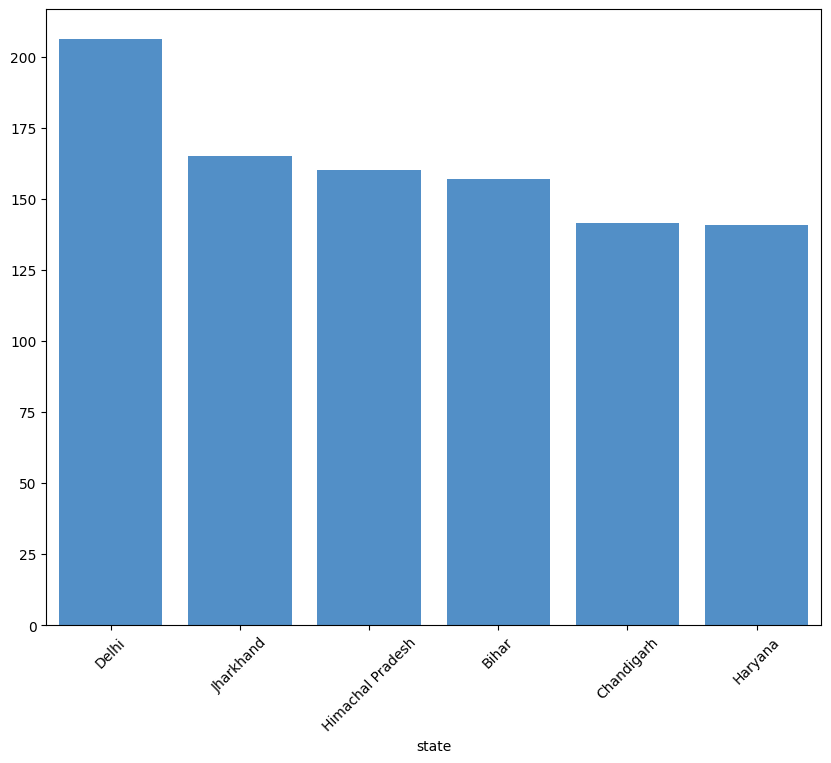

In [ ]:
plt.figure(figsize=(10,8))
plt.style.use('petroff10')
sns.barplot(x=state_aqi_min.index,y=state_aqi_min.values)
plt.xticks(rotation=45)
plt.show()

In [ ]:
df1

,state,area,number_of_monitoring_stations,prominent_pollutants,aqi_value,air_quality_status
0,Maharashtra,Amravati,2,PM10,78,Satisfactory
1,Bihar,Purnia,1,CO,56,Satisfactory
2,Madhya Pradesh,Katni,1,O3,98,Satisfactory
3,Chhattisgarh,Tumidih,1,PM10,103,Moderate
4,Assam,Byrnihat,1,PM2.5,61,Satisfactory
...,...,...,...,...,...,...
235780,Bihar,Arrah,1,PM10,210,Poor
235781,Rajasthan,Jaipur,3,"PM2.5,PM10",158,Moderate
235782,Maharashtra,Chandrapur,2,PM2.5,201,Poor
235783,Uttar Pradesh,Varanasi,4,PM10,128,Moderate


In [ ]:
s=df1.groupby(['prominent_pollutants'])['state'].count().sort_values(ascending=False).head()

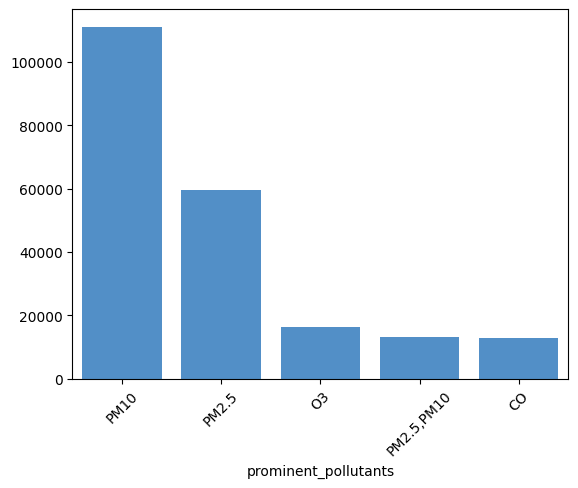

In [ ]:
sns.barplot(x=s.index,y=s.values)
plt.xticks(rotation=45)
plt.show()

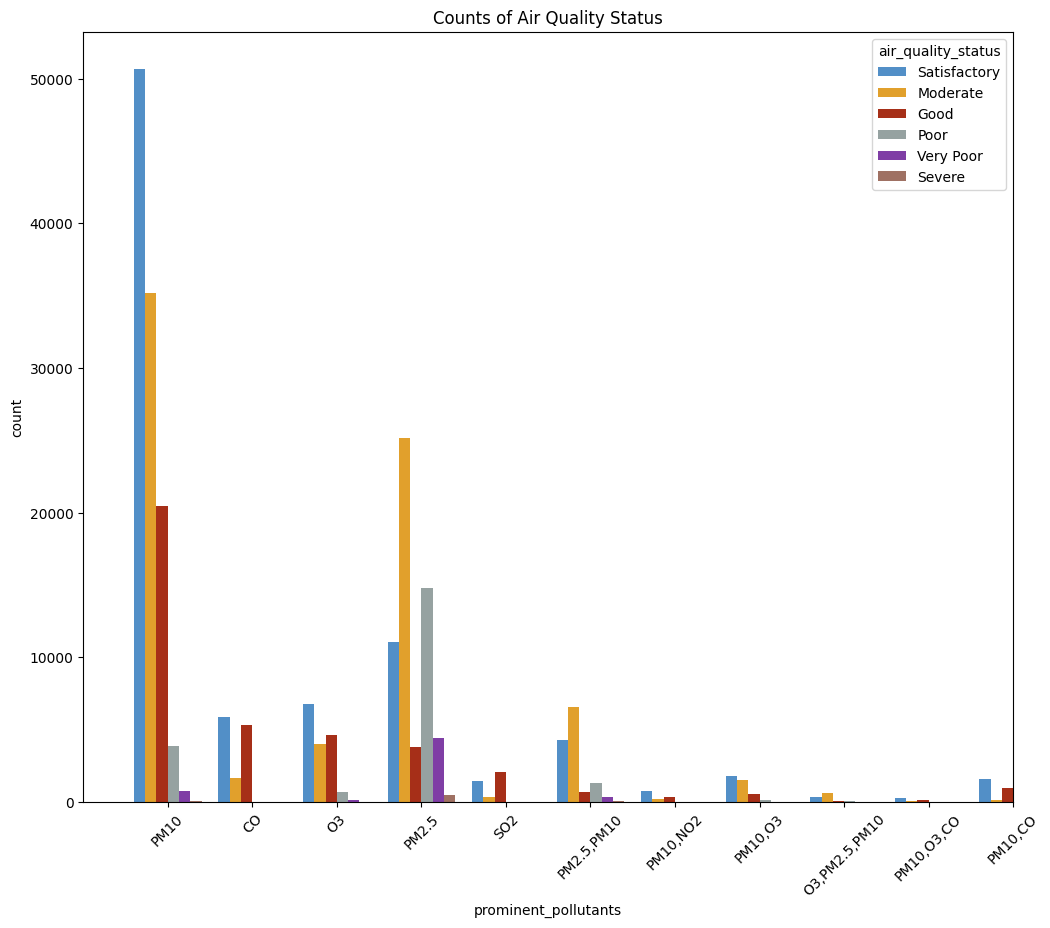

In [ ]:
plt.figure(figsize=(12,10))
sns.countplot(x='prominent_pollutants',data=df1,hue='air_quality_status')
plt.xlim(-1,10)
plt.xticks(rotation=45)
plt.title('Counts of Air Quality Status')
plt.show()

In [ ]:
state_aqi_stations = df1.groupby(['air_quality_status','state'])['number_of_monitoring_stations'].mean().sort_values(ascending=False).head(30)
state_aqi_stations

,,number_of_monitoring_stations
air_quality_status,state,
Very Poor,Delhi,36.039604
Severe,Delhi,35.736842
Poor,Delhi,35.562500
Moderate,Delhi,35.062035
Satisfactory,Delhi,32.989474
Good,Delhi,27.250000
Moderate,Telangana,11.423423
Good,Telangana,11.268293
Satisfactory,Telangana,11.160780


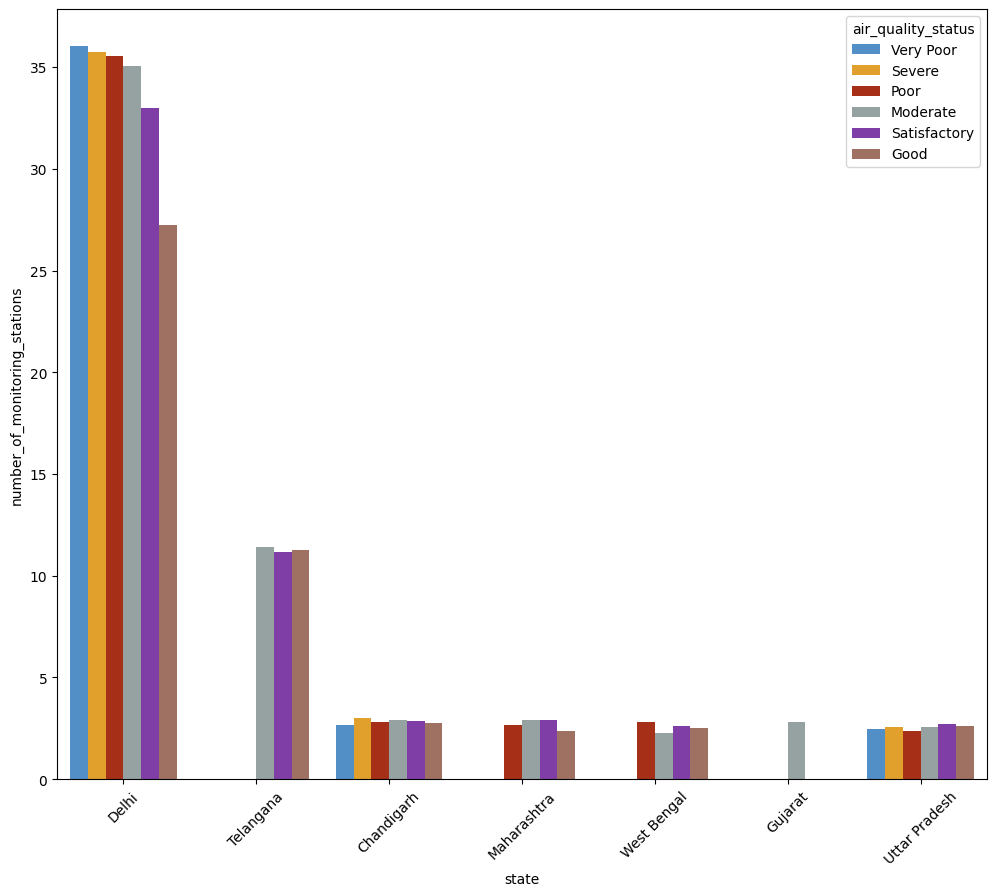

In [ ]:
plt.figure(figsize=(12,10))
state_aqi_stations_df = state_aqi_stations.reset_index()
sns.barplot(x='state',y='number_of_monitoring_stations',hue='air_quality_status',data=state_aqi_stations_df)
plt.xticks(rotation=45)
plt.show()

In [ ]:
area_aqi_min=df1.groupby(['air_quality_status','state'])['aqi_value'].mean().sort_values(ascending=False).head(30)
area_aqi_min

air_quality_status  state           
Severe              Meghalaya           484.000000
                    Karnataka           471.666667
                    Manipur             462.000000
                    Maharashtra         460.000000
                    Andhra Pradesh      459.000000
                    Madhya Pradesh      452.500000
                    Jharkhand           436.000000
                    Delhi               427.289474
                    Bihar               425.976431
                    Haryana             424.887640
                    Uttar Pradesh       424.739130
                    Rajasthan           420.347826
                    Assam               415.705882
                    Himachal Pradesh    415.500000
                    Punjab              412.500000
                    Chandigarh          412.000000
                    Odisha              406.000000
Very Poor           Delhi               347.009901
                    Karnataka           342.250000
                    Bihar               341.963749
                    Himachal Pradesh    338.900000
                    Jharkhand           338.000000
                    Uttar Pradesh       336.429907
                    Assam               335.321569
                    Punjab              334.182796
                    Rajasthan           334.054750
                    Haryana             334.005000
                    Chandigarh          333.217391
                    Madhya Pradesh      330.341317
                    Tamil Nadu          329.080000
Name: aqi_value, dtype: float64

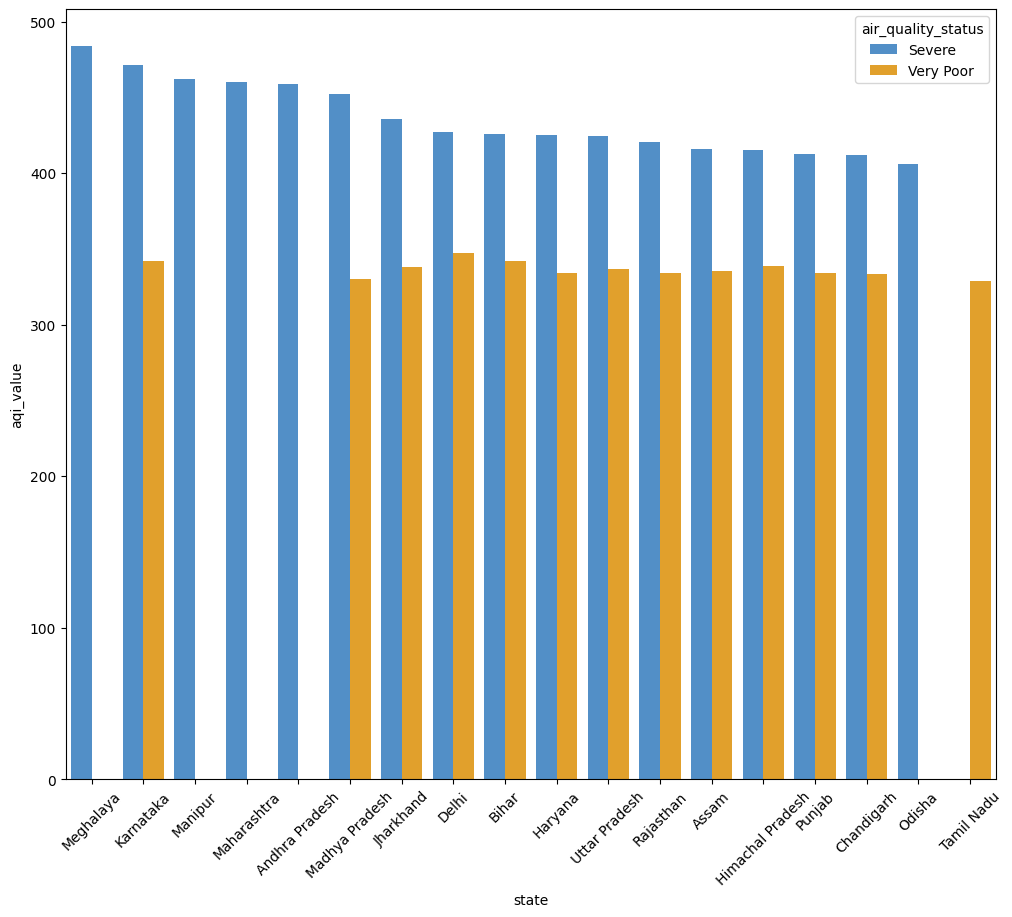

In [ ]:
plt.figure(figsize=(12,10))
sns.barplot(x ='state',y='aqi_value',hue='air_quality_status',data=area_aqi_min.reset_index())
plt.xticks(rotation=45)
plt.show()

In [ ]:
area_aqi_max=df1.groupby(['air_quality_status','state'])['aqi_value'].mean().sort_values().head(40)
area_aqi_max

air_quality_status  state                      
Good                Mizoram                        27.274603
                    Jharkhand                      28.857143
                    Meghalaya                      30.622601
                    Sikkim                         31.796915
                    Arunachal Pradesh              31.879121
                    Andaman and Nicobar Islands    35.500000
                    Tamil Nadu                     35.863290
                    Uttarakhand                    36.904580
                    Chhattisgarh                   37.181255
                    Assam                          37.202426
                    Tripura                        38.395455
                    Madhya Pradesh                 38.600970
                    Andhra Pradesh                 38.634170
                    Maharashtra                    39.162147
                    Karnataka                      39.438703
                    Puducherry                     39.472795
                    Bihar                          39.555851
                    Uttar Pradesh                  39.675385
                    West Bengal                    39.702741
                    Odisha                         40.160247
                    Gujarat                        40.209857
                    Jammu and Kashmir              40.641618
                    Kerala                         40.748808
                    Haryana                        41.161952
                    Rajasthan                      41.483893
                    Punjab                         41.809605
                    Manipur                        43.066667
                    Chandigarh                     44.238095
                    Himachal Pradesh               44.363636
                    Nagaland                       44.937824
                    Delhi                          46.000000
                    Telangana                      46.036585
Satisfactory        Sikkim                         63.020356
                    Puducherry                     65.482328
                    Assam                          67.281016
                    Kerala                         68.021643
                    Andaman and Nicobar Islands    69.142857
                    Nagaland                       69.352381
                    Karnataka                      69.480508
                    Arunachal Pradesh              70.596859
Name: aqi_value, dtype: float64

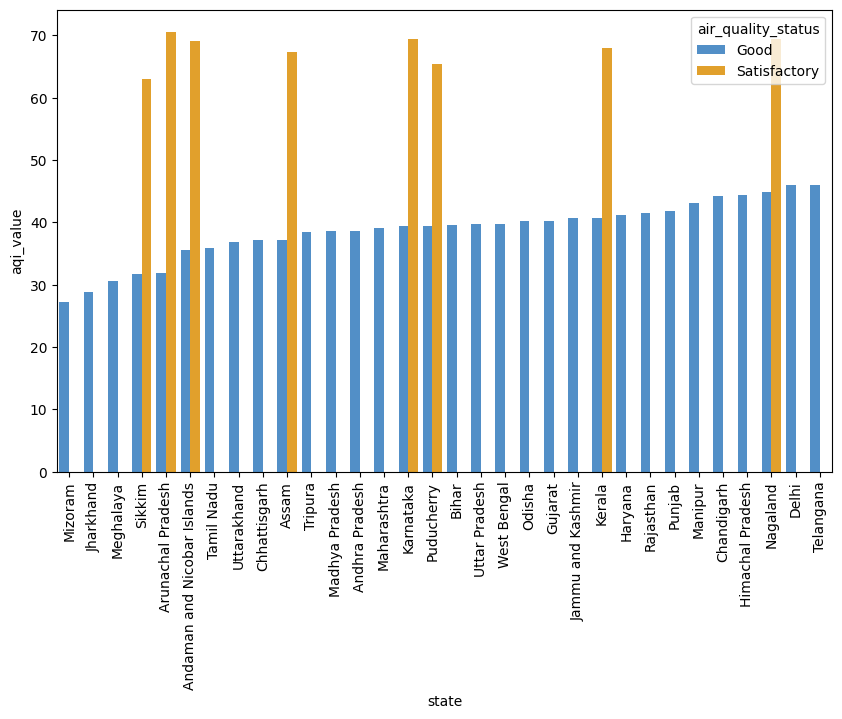

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x ='state',y='aqi_value',hue='air_quality_status',data=area_aqi_max.reset_index())
plt.xticks(rotation=90)
plt.show()

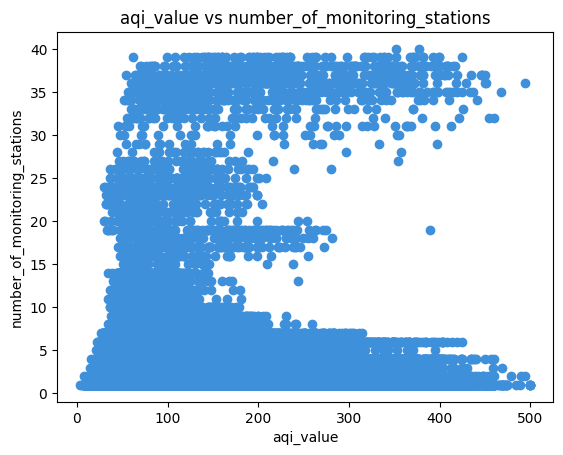

In [ ]:
plt.scatter(df1['aqi_value'],df1['number_of_monitoring_stations'])
plt.xlabel('aqi_value')
plt.ylabel('number_of_monitoring_stations')
plt.title('aqi_value vs number_of_monitoring_stations')
plt.show()

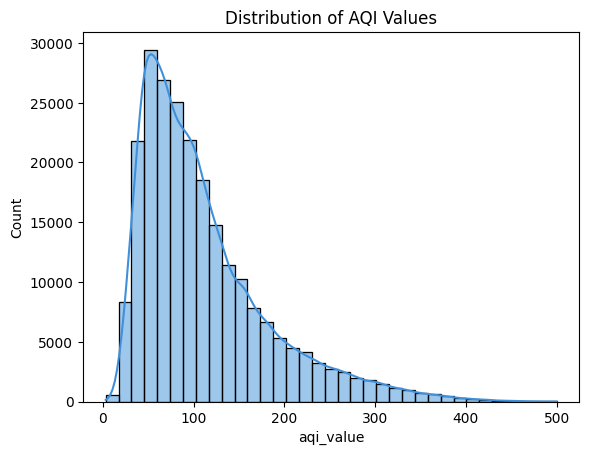

In [ ]:
sns.histplot(df1['aqi_value'],kde=True,bins=35)
plt.title('Distribution of AQI Values')
plt.show()

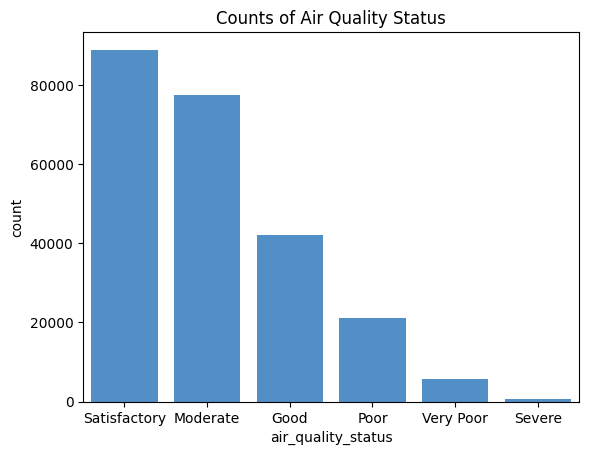

In [ ]:
sns.countplot(x='air_quality_status',data=df1)
plt.title('Counts of Air Quality Status')
plt.show()

In [ ]:
state_area_max= df1.groupby(['state','area'])['aqi_value'].max().sort_values(ascending=False).head()
state_area_max

,,aqi_value
state,area,
Manipur,Imphal,500
Andhra Pradesh,Vijayawada,500
Karnataka,Gadag,500
Madhya Pradesh,Ujjain,500
Uttar Pradesh,Greater Noida,494


In [ ]:
state_area_min= df1.groupby(['state','area'])['aqi_value'].max().sort_values().head()
state_area_min

state       area       
Tamil Nadu  Tirunelveli    49
            Namakkal       82
Assam       Silchar        89
            Sivasagar      91
Karnataka   Mysuru         92
Name: aqi_value, dtype: int64

In [ ]:
df1.columns

Index(['state', 'area', 'number_of_monitoring_stations',
       'prominent_pollutants', 'aqi_value', 'air_quality_status'],
      dtype='object')

In [ ]:
df1.groupby(['state','area'])['number_of_monitoring_stations'].mean().head()

state                        area            
Andaman and Nicobar Islands  Sri Vijaya Puram    1.0
Andhra Pradesh               Amaravati           1.0
                             Anantapur           1.0
                             Chittoor            1.0
                             Kadapa              1.0
Name: number_of_monitoring_stations, dtype: float64

In [ ]:
df1.columns

Index(['state', 'area', 'number_of_monitoring_stations',
       'prominent_pollutants', 'aqi_value', 'air_quality_status'],
      dtype='object')

In [ ]:
df1.groupby(['state','prominent_pollutants'])['aqi_value'].value_counts().head()

state                        prominent_pollutants  aqi_value
Andaman and Nicobar Islands  CO                    28           2
                                                   30           1
                                                   31           1
                                                   33           1
                                                   37           1
Name: count, dtype: int64

In [ ]:
encoder= OneHotEncoder(drop='first',sparse_output=False)

encode=encoder.fit_transform(df1[['prominent_pollutants']])

encode

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
encode_df=pd.DataFrame(encode,columns=encoder.get_feature_names_out())

encode_df

,"prominent_pollutants_CO,NO2","prominent_pollutants_CO,O3","prominent_pollutants_CO,SO2",prominent_pollutants_NH3,"prominent_pollutants_NH3,CO,O3",prominent_pollutants_NO2,"prominent_pollutants_NO2,CO,O3","prominent_pollutants_NO2,O3","prominent_pollutants_NO2,O3,SO2","prominent_pollutants_NO2,PM10,CO",...,"prominent_pollutants_PM2.5,NO2","prominent_pollutants_PM2.5,NO2,SO2","prominent_pollutants_PM2.5,O3","prominent_pollutants_PM2.5,PM10","prominent_pollutants_PM2.5,PM10,CO","prominent_pollutants_PM2.5,SO2","prominent_pollutants_PM2.5,SO2,O3",prominent_pollutants_SO2,"prominent_pollutants_SO2,O3","prominent_pollutants_SO3,CO,O3"
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235780,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
235781,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
235782,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
235783,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df2= pd.concat([df1,encode_df],axis=1)

df2

,state,area,number_of_monitoring_stations,prominent_pollutants,aqi_value,air_quality_status,"prominent_pollutants_CO,NO2","prominent_pollutants_CO,O3","prominent_pollutants_CO,SO2",prominent_pollutants_NH3,...,"prominent_pollutants_PM2.5,NO2","prominent_pollutants_PM2.5,NO2,SO2","prominent_pollutants_PM2.5,O3","prominent_pollutants_PM2.5,PM10","prominent_pollutants_PM2.5,PM10,CO","prominent_pollutants_PM2.5,SO2","prominent_pollutants_PM2.5,SO2,O3",prominent_pollutants_SO2,"prominent_pollutants_SO2,O3","prominent_pollutants_SO3,CO,O3"
0,Maharashtra,Amravati,2,PM10,78,Satisfactory,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Bihar,Purnia,1,CO,56,Satisfactory,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Madhya Pradesh,Katni,1,O3,98,Satisfactory,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Chhattisgarh,Tumidih,1,PM10,103,Moderate,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Assam,Byrnihat,1,PM2.5,61,Satisfactory,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235780,Bihar,Arrah,1,PM10,210,Poor,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
235781,Rajasthan,Jaipur,3,"PM2.5,PM10",158,Moderate,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
235782,Maharashtra,Chandrapur,2,PM2.5,201,Poor,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
235783,Uttar Pradesh,Varanasi,4,PM10,128,Moderate,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df2.isnull().sum()

,0
state,0
area,0
number_of_monitoring_stations,0
prominent_pollutants,0
aqi_value,0
air_quality_status,0
"prominent_pollutants_CO,NO2",0
"prominent_pollutants_CO,O3",0
"prominent_pollutants_CO,SO2",0
prominent_pollutants_NH3,0


In [ ]:
df2.drop(columns=['prominent_pollutants'],inplace=True,axis=1)

In [ ]:
df2

,state,area,number_of_monitoring_stations,aqi_value,air_quality_status,"prominent_pollutants_CO,NO2","prominent_pollutants_CO,O3","prominent_pollutants_CO,SO2",prominent_pollutants_NH3,"prominent_pollutants_NH3,CO,O3",...,"prominent_pollutants_PM2.5,NO2","prominent_pollutants_PM2.5,NO2,SO2","prominent_pollutants_PM2.5,O3","prominent_pollutants_PM2.5,PM10","prominent_pollutants_PM2.5,PM10,CO","prominent_pollutants_PM2.5,SO2","prominent_pollutants_PM2.5,SO2,O3",prominent_pollutants_SO2,"prominent_pollutants_SO2,O3","prominent_pollutants_SO3,CO,O3"
0,Maharashtra,Amravati,2,78,Satisfactory,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Bihar,Purnia,1,56,Satisfactory,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Madhya Pradesh,Katni,1,98,Satisfactory,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Chhattisgarh,Tumidih,1,103,Moderate,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Assam,Byrnihat,1,61,Satisfactory,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235780,Bihar,Arrah,1,210,Poor,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
235781,Rajasthan,Jaipur,3,158,Moderate,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
235782,Maharashtra,Chandrapur,2,201,Poor,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
235783,Uttar Pradesh,Varanasi,4,128,Moderate,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
features = ['aqi_value','number_of_monitoring_stations']

le = LabelEncoder()
df2['target'] = le.fit_transform(df2['air_quality_status'])

X = df2[features]
y = df2['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model=LogisticRegression(multi_class="multinomial", solver="lbfgs")
model.fit(X_train,y_train)

print('Accuracy',model.score(X_test,y_test))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy 0.8247768093814279


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
predictions = model.predict(X_test)
print(predictions)

[0 0 3 ... 3 1 3]


In [ ]:
import numpy as np
import pandas as pd

# Generate random data for prediction
# Based on df1.describe(), aqi_value ranges from 3 to 500, and number_of_monitoring_stations from 1 to 40
random_aqi_values = np.random.randint(3, 501, size=10) # 10 random AQI values
random_monitoring_stations = np.random.randint(1, 41, size=10) # 10 random monitoring station counts

random_data = pd.DataFrame({
    'aqi_value': random_aqi_values,
    'number_of_monitoring_stations': random_monitoring_stations,

})
display(random_data)

,aqi_value,number_of_monitoring_stations
0,118,17
1,316,16
2,355,4
3,394,23
4,116,11
5,80,29
6,141,5
7,453,3
8,173,35
9,335,18


In [ ]:
# Make predictions on the random data
random_predictions = model.predict(random_data)

# Convert numerical predictions back to original air_quality_status labels
predicted_status = le.inverse_transform(random_predictions)

print("Predictions for random data:")
for i, (aqi, stations) in enumerate(zip(random_data['aqi_value'], random_data['number_of_monitoring_stations'])):
    print(f"AQI: {aqi}, Monitoring Stations: {stations} -> Predicted Status: {predicted_status[i]}")

Predictions for random data:
AQI: 118, Monitoring Stations: 17 -> Predicted Status: Satisfactory
AQI: 316, Monitoring Stations: 16 -> Predicted Status: Poor
AQI: 355, Monitoring Stations: 4 -> Predicted Status: Poor
AQI: 394, Monitoring Stations: 23 -> Predicted Status: Poor
AQI: 116, Monitoring Stations: 11 -> Predicted Status: Satisfactory
AQI: 80, Monitoring Stations: 29 -> Predicted Status: Satisfactory
AQI: 141, Monitoring Stations: 5 -> Predicted Status: Moderate
AQI: 453, Monitoring Stations: 3 -> Predicted Status: Poor
AQI: 173, Monitoring Stations: 35 -> Predicted Status: Satisfactory
AQI: 335, Monitoring Stations: 18 -> Predicted Status: Poor


In [ ]:
# Install mord if it's not already installed
!pip install mord

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import mord
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

  Preparing metadata (setup.py) ... done
  Created wheel for mord: filename=mord-0.7-py3-none-any.whl size=9885 sha256=c89db334d71bef330b2a1f2c78511fcbf82e7dda723afbf6468a7e936b764e89
  Stored in directory: /root/.cache/pip/wheels/80/3e/3b/13f1adf346cad0fec675db328e4b0d814795c6c8e2fb659122
Successfully built mord


In [ ]:
features = ['aqi_value','number_of_monitoring_stations']

le = LabelEncoder()
df2['target'] = le.fit_transform(df2['air_quality_status'])

X = df2[features]
y = df2['target']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

model = mord.LogisticIT()
model.fit(X_train, y_train)
print('Accuracy',model.score(X_test,y_test))
pred = model.predict(X_test)

# print("Prediction:",pred)

Accuracy 0.04455330067646373


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    log_loss
)

cm=confusion_matrix(y_test,pred)
print(cm)

[[    0  8426     0    14     0     0]
 [    0  1620     0 13831     0     0]
 [    0     0     0  4252     0     0]
 [    0 17233     0   481     0     0]
 [    0     0     0   118     0     0]
 [    0     0     0  1182     0     0]]


In [ ]:
acc = accuracy_score(y_test, pred)
print("Accuracy:", acc)

Accuracy: 0.04455330067646373


In [ ]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score



le = LabelEncoder()
df2['state'] = le.fit_transform(df2['state'])
df2['area'] = le.fit_transform(df2['area'])

features = ['aqi_value','number_of_monitoring_stations','state','area']
df2['target'] = le.fit_transform(df2['air_quality_status'])

X = df2[features]
y = df2['target']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

tree_model = DecisionTreeRegressor(max_depth=3)
tree_model.fit(X_train, y_train)

print('Accuracy',tree_model.score(X_test,y_test))

Accuracy 0.9544412507814884


In [ ]:
# from sklearn.model_selection import cross_val_score
# from sklearn.linear_model import LogisticRegression
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import LabelEncoder


# le = LabelEncoder()
# df2['state'] = le.fit_transform(df2['state'])
# df2['area'] = le.fit_transform(df2['area'])

# features = ['aqi_value','number_of_monitoring_stations','state','area']
# df2['target'] = le.fit_transform(df2['air_quality_status'])

# X = df2[features]
# y = df2['target']
# # X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

# model = LogisticRegression(max_iter=300)
# scores = cross_val_score(model, X, y, cv=10)
# print("Cross-validation scores:", scores)

# print('Accuracy',scores.mean())


In [ ]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score



le = LabelEncoder()
df2['state'] = le.fit_transform(df2['state'])
df2['area'] = le.fit_transform(df2['area'])

features = ['aqi_value','number_of_monitoring_stations','state','area']
df2['target'] = le.fit_transform(df2['air_quality_status'])

X = df2[features]
y = df2['target']
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42)

tree_model = DecisionTreeClassifier(max_depth=3)
tree_model.fit(X_train, y_train)

# print('Accuracy',tree_model.score(X_test,y_test))
pred= tree_model.predict(X_test)
print("Accuracy",accuracy_score(y_test,pred))

Accuracy 0.9975401631974485


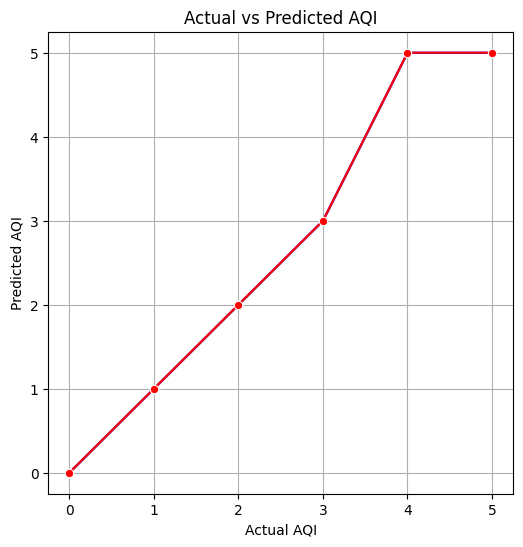

In [ ]:
plt.figure(figsize=(6,6))
pred = tree_model.predict(X_test) # Recalculate pred to match current X_test
sns.lineplot(x=y_test, y=pred,marker='o', color='blue')
sns.lineplot(x=y_train, y=tree_model.predict(X_train), marker='o',color='red')
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,pred)
print(cm)

[[10533     0     0     0     0     0]
 [    0 19328     0     0     0     0]
 [    0     0  5306     0     0     0]
 [    0     0     0 22162     0     0]
 [    0     0     0     0     0   145]
 [    0     0     0     0     0  1473]]


In [ ]:
import pickle
pickle.dump(model,open('Dtree_model.pkl','wb'))

In [ ]:
import pickle
from sklearn.metrics import accuracy_score

In [ ]:
Decision_tree = pickle.load(open('Dtree_model.pkl','rb'))
t_pred= Decision_tree.predict(X_test)
print('Accuracy',accuracy_score(y_test,t_pred))

ValueError: Dot product shape mismatch, (58947, 4) vs (2,)

In [ ]:
param_grid = {
    'criterion': ['gini', 'entropy'],     # how split is calculated
    'max_depth': [None, 3, 5, 10],        # depth of tree
    'min_samples_split': [2, 5, 10],      # split condition
    'min_samples_leaf': [1, 2, 4]         # leaf size
}

In [ ]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    estimator= tree_model,
    param_grid= param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid.fit(X_train, y_train)

In [ ]:
print("Best Parameter",grid.best_params_)
print("Best Score",grid.best_score_)

In [ ]:
best_model = grid.best_estimator_
accuracy = best_model.score(X_test, y_test)
print("Test Accuracy:", accuracy)

In [ ]:
pred= grid.predict(X_test)
print("Accuracy",accuracy_score(y_test,pred))

In [ ]:
import numpy as np
import pandas as pd

# Generate random data for prediction
# Based on df1.describe(), aqi_value ranges from 3 to 500, and number_of_monitoring_stations from 1 to 40
random_aqi_values = np.random.randint(3, 501, size=10) # 10 random AQI values
random_monitoring_stations = np.random.randint(1, 41, size=10) # 10 random monitoring station counts
# Assuming df2['state'] and df2['area'] are already label encoded from previous cells.
# Get the max encoded values to generate random numbers within that range
max_encoded_state = df2['state'].max()
max_encoded_area = df2['area'].max()

# Generate random encoded values for 'state' and 'area'
random_encoded_states = np.random.randint(0, max_encoded_state + 1, size=10)
random_encoded_areas = np.random.randint(0, max_encoded_area + 1, size=10)

# Create a new DataFrame for prediction with numerical 'state' and 'area'
random_data_numerical = pd.DataFrame({
    'aqi_value': random_aqi_values,
    'number_of_monitoring_stations': random_monitoring_stations,
    'state': random_encoded_states,
    'area': random_encoded_areas
})
display(random_data)

In [ ]:


# Make predictions on the numerical random data
random_predictions = grid.predict(random_data_numerical)

# Convert numerical predictions back to original air_quality_status labels
# The 'le' object is correctly configured for 'air_quality_status' (target)
predicted_status = le.inverse_transform(random_predictions)

print("Predictions for random data:")
for i, (aqi, stations, state_enc, area_enc) in enumerate(zip(
    random_data_numerical['aqi_value'],
    random_data_numerical['number_of_monitoring_stations'],
    random_data_numerical['state'],
    random_data_numerical['area']
)):
    print(f"AQI: {aqi}, Monitoring Stations: {stations}, State (encoded): {state_enc}, Area (encoded): {area_enc} -> Predicted Status: {predicted_status[i]}")

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

le = LabelEncoder()
df2['state'] = le.fit_transform(df2['state'])
df2['area'] = le.fit_transform(df2['area'])

features = ['aqi_value','number_of_monitoring_stations','state','area']
df2['target'] = le.fit_transform(df2['air_quality_status'])

X = df2[features]
y = df2['target']
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42)

knn = KNeighborsClassifier()
knn.fit(X, y)
pred_k = knn.predict(X_test)
print("Accuracy",accuracy_score(y_test,pred_k))

In [ ]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,pred_k)
print(cm)

In [ ]:
param_grid={
    'n_neighbors':[3,5,7,9,11],
}

In [ ]:
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(
    estimator= knn,
    param_grid= param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid.fit(X_train, y_train)

In [ ]:
print("Best Parameter",grid.best_params_)
print("Best Score",grid.best_score_)

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

le = LabelEncoder()
df2['state'] = le.fit_transform(df2['state'])
df2['area'] = le.fit_transform(df2['area'])

features = ['aqi_value','number_of_monitoring_stations','state','area']
df2['target'] = le.fit_transform(df2['air_quality_status'])

X = df2[features]
y = df2['target']
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42)

mul_model = MultinomialNB()
mul_model.fit(X_train, y_train)

print('Accuracy',mul_model.score(X_test,y_test))
#

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


le = LabelEncoder()
df2['state'] = le.fit_transform(df2['state'])
df2['area'] = le.fit_transform(df2['area'])

features = ['aqi_value','number_of_monitoring_stations','state','area']
df2['target'] = le.fit_transform(df2['air_quality_status'])

X = df2[features]
y = df2['target']
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_features='sqrt',
    bootstrap=True,
    oob_score=True,
    random_state=42
)
rf_model.fit(X_train,y_train)

print('oob_score',rf_model.oob_score_)
# y_pred = rf_model.predict(X_test)
# print("Accuracy:", accuracy_score(y_test, y_pred))

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


le = LabelEncoder()
df2['state'] = le.fit_transform(df2['state'])
df2['area'] = le.fit_transform(df2['area'])

features = ['aqi_value','number_of_monitoring_stations','state','area']
df2['target'] = le.fit_transform(df2['air_quality_status'])

X = df2[features]
y = df2['target']
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42)

base_model = DecisionTreeClassifier(max_depth=1)

model = AdaBoostClassifier(
    estimator=base_model,
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)


model.fit(X_train, y_train)


y_pred = model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))

In [ ]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
print(cm)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test.values[:100], label="Actual")
plt.plot(y_pred[:100], label="Predicted")

plt.legend()
plt.xlabel("Samples")
plt.ylabel("AQI")
plt.title("Actual vs Predicted AQI")

plt.show()

In [ ]:
plt.figure(figsize=(6,6))
sns.lineplot(x=y_test, y=y_pred,marker='o', color='blue')
# plt.plot(y_train, model.predict(X_train), color='red')
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI")
plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(6,6))
sns.lineplot(x=y_train, y=model.predict(X_train), marker='o',color='red')
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI")
plt.grid(True)
plt.show()

In [ ]:
import pickle
pickle.dump(model,open('model.pkl','wb'))

In [ ]:
l=pickle.load(open('model.pkl','rb'))


In [ ]:
l.predict(X_test)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

features = ['aqi_value','number_of_monitoring_stations','state','area']

df2['target'] = df2['air_quality_status']

X = df2[features]
y = df2['target']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['state','area'])
    ],
    remainder='passthrough'
)

X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=42)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_features='sqrt',
    bootstrap=True,
    oob_score=True,
    random_state=42
)

pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('classifier',rf_model)
])

pipeline.fit(X_train,y_train)

print("Model Score:",pipeline.score(X_test,y_test))

Model Score: 0.9995080326394897


In [ ]:
import pickle
pickle.dump(pipeline,open('pipeline.pkl','wb'))

In [ ]:
rf_model_pipeline = pickle.load(open('pipeline.pkl','rb'))

In [ ]:
pred_rf = rf_model_pipeline.predict(X_test)
print(pred_rf)

['Good' 'Good' 'Satisfactory' ... 'Moderate' 'Poor' 'Moderate']


In [ ]:
print("Accuracy",accuracy_score(y_test,pred_rf))

In [ ]:
pred_Y = pipeline.predict(X_test)
print("Accuracy",accuracy_score(y_test,pred_Y))

Accuracy 0.9995080326394897


In [ ]:
print(pred_Y)

['Good' 'Good' 'Satisfactory' ... 'Moderate' 'Poor' 'Moderate']


In [ ]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,pred_Y)
print(cm)

[[10533     0     0     0     0     0]
 [    0 19326     2     0     0     0]
 [    0     4  5299     0     0     3]
 [    0     0     0 22162     0     0]
 [    0     0     2     0   136     7]
 [    0     0    11     0     0  1462]]


In [ ]:
import numpy as np
import pandas as pd

# Generate random data for prediction
# Based on df1.describe(), aqi_value ranges from 3 to 500, and number_of_monitoring_stations from 1 to 40
random_aqi_values = np.random.randint(3, 501, size=10) # 10 random AQI values
random_monitoring_stations = np.random.randint(1, 41, size=10) # 10 random monitoring station counts
# Assuming df2['state'] and df2['area'] are already label encoded from previous cells.
# Get the max encoded values to generate random numbers within that range
max_encoded_state = df2['state'].max()
max_encoded_area = df2['area'].max()

# Generate random encoded values for 'state' and 'area'
random_encoded_states = np.random.randint(0, max_encoded_state + 1, size=10)
random_encoded_areas = np.random.randint(0, max_encoded_area + 1, size=10)

# Create a new DataFrame for prediction with numerical 'state' and 'area'
random_data_numerical = pd.DataFrame({
    'aqi_value': random_aqi_values,
    'number_of_monitoring_stations': random_monitoring_stations,
    'state': random_encoded_states,
    'area': random_encoded_areas
})
display(random_data)

In [ ]:
# Make predictions on the numerical random data
random_predictions = pipeline.predict(random_data_numerical)

# The random_predictions already contain the original string labels,
# so inverse_transform is not needed.
predicted_status = random_predictions

print("Predictions for random data:")
for i, (aqi, stations, state_enc, area_enc) in enumerate(zip(
    random_data_numerical['aqi_value'],
    random_data_numerical['number_of_monitoring_stations'],
    random_data_numerical['state'],
    random_data_numerical['area']
)):
    print(f"AQI: {aqi}, Monitoring Stations: {stations}, State (encoded): {state_enc}, Area (encoded): {area_enc} -> Predicted Status: {predicted_status[i]}")